# **GRUPO 17**
**Integrantes:**


*   Jair Morales Martinez
*   Kevin Solis
*   Cristian Alejandro Veloz Armas

In [96]:
#@title Importar librerías
#importar librerías necesarias
import numpy as np                       # Para manejar arreglos numéricos (imágenes como matrices)
import matplotlib.pyplot as plt          # Para graficar y visualizar imágenes
import skimage.io as io                  # skimage.io: para leer y guardar imágenes
from skimage import filters, img_as_float, exposure  # Funciones de procesamiento de imágenes
from sklearn.model_selection import train_test_split
import os                                # Manejo de directorios (acceso a carpetas, archivos)
import random                            # Para seleccionar imágenes aleatorias del dataset
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator                               # OpenCV: librería usada en procesamiento de imágenes

# Filtros avanzados de suavizado (bilateral)
from skimage.restoration import denoise_bilateral

# Configuración de Matplotlib para mostrar gráficos en la misma celda
%matplotlib inline

In [97]:
# 1. INSTALACIÓN DE LIBRERÍAS
!pip install brisque
!pip install bm3d

# Analisis del Dataset

Trabajaremos con el dataset de lenguaje de señas de Kaggle.


In [98]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
#@title Importar dataset

x_load = np.load('/content/drive/MyDrive/IA - Notebooks/Master en IA/Modulo3_Aprendizaje profundo/Señales-tarea2/X.npy')
y_load = np.load('/content/drive/MyDrive/IA - Notebooks/Master en IA/Modulo3_Aprendizaje profundo/Señales-tarea2/Y.npy')

img_size = 64



In [100]:
print("Shape de X:", x_load.shape)
print("Shape de Y:", y_load.shape)
print("Tipo de datos:", x_load.dtype)


Shape de X: (2062, 64, 64)
Shape de Y: (2062, 10)
Tipo de datos: float32


In [101]:
x_load[0].squeeze()

array([[0.46666667, 0.4745098 , 0.47843137, ..., 0.5176471 , 0.5137255 ,
        0.5019608 ],
       [0.49803922, 0.4862745 , 0.4862745 , ..., 0.5254902 , 0.5176471 ,
        0.50980395],
       [0.54509807, 0.49411765, 0.49019608, ..., 0.5294118 , 0.5254902 ,
        0.5137255 ],
       ...,
       [0.5019608 , 0.5137255 , 0.5176471 , ..., 0.5529412 , 0.54509807,
        0.53333336],
       [0.49803922, 0.5058824 , 0.5137255 , ..., 0.54509807, 0.53333336,
        0.52156866],
       [0.49019608, 0.49803922, 0.5019608 , ..., 0.5294118 , 0.52156866,
        0.50980395]], dtype=float32)

In [102]:
import numpy as np
import pandas as pd

# Obtener un vector representativo por cada clase (0 al 9)
representative_vectors = []
for clase in range(10):
    idx = np.where(np.argmax(y_load, axis=1) == clase)[0][0]
    representative_vectors.append(y_load[idx])

# Convertir a DataFrame para visualizar
df_vectores = pd.DataFrame(representative_vectors, columns=[f'Clase_{i}' for i in range(10)])
df_vectores['Representa_Clase'] = np.argmax(df_vectores.values, axis=1)

print(df_vectores)


   Clase_0  Clase_1  Clase_2  Clase_3  Clase_4  Clase_5  Clase_6  Clase_7  \
0      1.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
2      0.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0   
3      0.0      0.0      0.0      1.0      0.0      0.0      0.0      0.0   
4      0.0      0.0      0.0      0.0      1.0      0.0      0.0      0.0   
5      0.0      0.0      0.0      0.0      0.0      1.0      0.0      0.0   
6      0.0      0.0      0.0      0.0      0.0      0.0      1.0      0.0   
7      0.0      0.0      0.0      0.0      0.0      0.0      0.0      1.0   
8      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
9      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   Clase_8  Clase_9  Representa_Clase  
0      0.0      0.0                 0  
1      0.0      0.0                 1  
2      0.0      0.0             

In [103]:
# Obtener etiquetas en formato entero
labels = np.argmax(y_load, axis=1)

# Contar cuántas imágenes hay por cada clase
unique_classes, counts = np.unique(labels, return_counts=True)

# Mostrar resultados
for cls, count in zip(unique_classes, counts):
    print(f"Clase {cls}: {count} imágenes")


Clase 0: 204 imágenes
Clase 1: 205 imágenes
Clase 2: 206 imágenes
Clase 3: 207 imágenes
Clase 4: 206 imágenes
Clase 5: 208 imágenes
Clase 6: 207 imágenes
Clase 7: 206 imágenes
Clase 8: 206 imágenes
Clase 9: 207 imágenes


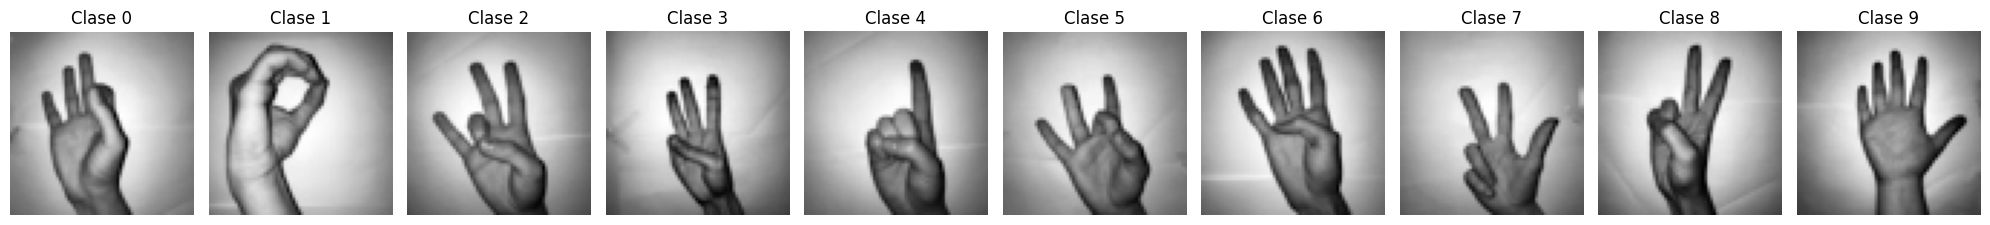

In [104]:
# === 1. IMPORTAR LIBRERÍAS ===
import numpy as np
import matplotlib.pyplot as plt


# === 3. AJUSTAR DIMENSIONES SI FALTAN CANALES ===
if x_load.ndim == 3:
    x_load = x_load.reshape(-1, 64, 64, 1)

# === 4. OBTENER LAS CLASES (CONVERTIR ONE-HOT A CLASE ENTERA) ===
labels = np.argmax(y_load, axis=1)
num_classes = len(np.unique(labels))

# === 5. MOSTRAR UNA IMAGEN REPRESENTATIVA DE CADA CLASE ===
fig, axes = plt.subplots(1, num_classes, figsize=(20, 3))

for clase in range(num_classes):
    idx = np.where(labels == clase)[0][0]  # Primer índice donde aparece la clase
    img = x_load[idx].squeeze()
    axes[clase].imshow(img, cmap='gray')
    axes[clase].set_title(f'Clase {clase}')
    axes[clase].axis('off')

plt.tight_layout()
plt.show()



In [105]:
# # Ajustar dimensiones
if x_load.ndim == 3:
    x_load = x_load.reshape(-1, 64, 64, 1)

# Convertir etiquetas one-hot a enteros
y_labels = np.argmax(y_load, axis=1)

# Agrupar imágenes por clase (según etiquetas correctas)
from collections import defaultdict
clases_dict = defaultdict(list)
for img, label in zip(x_load, y_labels):
    clases_dict[label].append(img)

# Reordenar imágenes y etiquetas
x_ordenado = []
y_ordenado = []
for clase in sorted(clases_dict.keys()):
    imgs = clases_dict[clase]
    x_ordenado.extend(imgs)
    y_ordenado.extend([clase] * len(imgs))

x_ordenado = np.array(x_ordenado)
y_ordenado = np.array(y_ordenado)
y_onehot = np.eye(10)[y_ordenado]

# Aplicar el nuevo mapeo corregido
nuevo_mapeo = {
    0: 9,
    1: 0,
    2: 7,
    3: 6,
    4: 1,
    5: 8,
    6: 4,
    7: 3,
    8: 2,
    9: 5
}

x_orde = []
y_orde = []

y_actuales = np.argmax(y_onehot, axis=1)
for i in range(len(x_ordenado)):
    clase_actual = y_actuales[i]
    clase_corregida = nuevo_mapeo[clase_actual]
    x_orde.append(x_ordenado[i])
    y_orde.append(clase_corregida)

x_orde = np.array(x_orde)
y_orde = np.array(y_orde)
y_orde_onehot = np.eye(10)[y_orde]

# Verificar resultado
x_orde.shape, y_orde_onehot.shape



((2062, 64, 64, 1), (2062, 10))

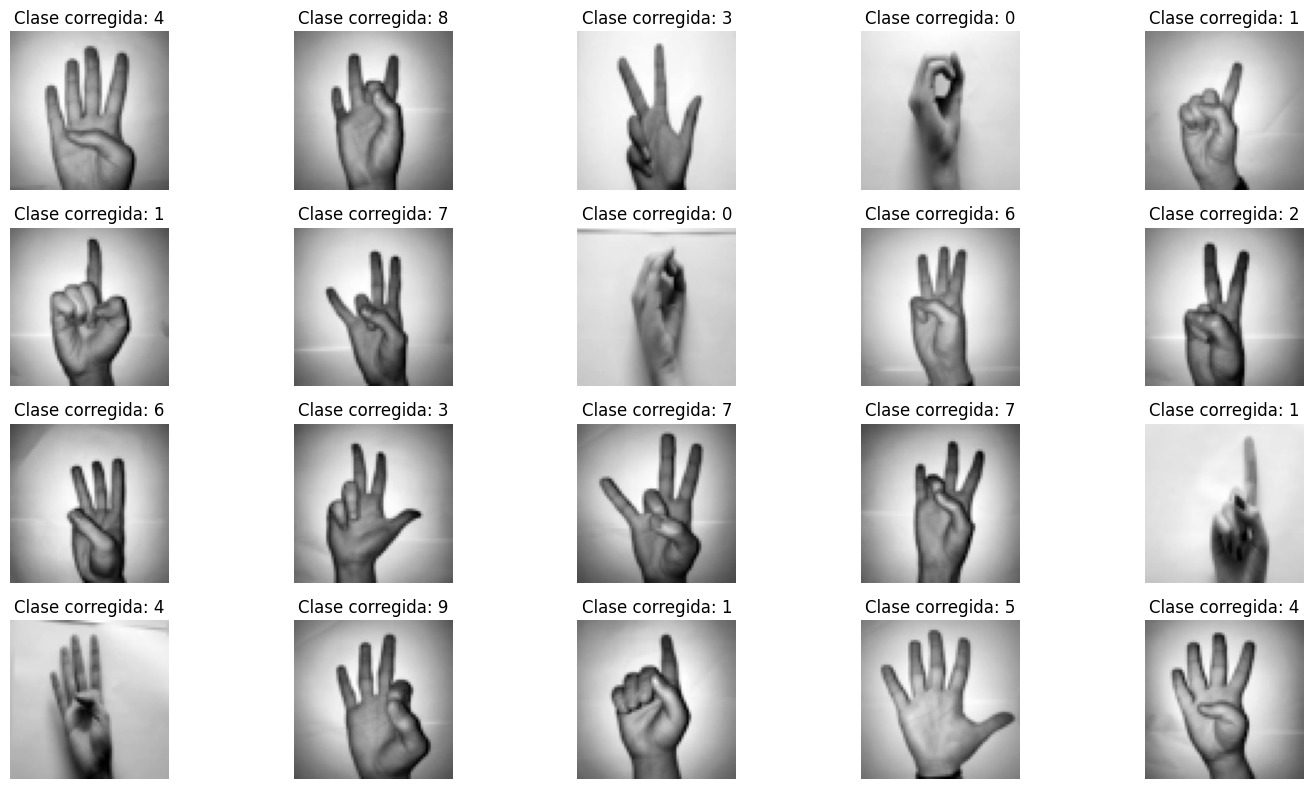

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Mostrar 20 imágenes aleatorias del dataset reordenado usando x_orde y y_orde
indices = np.random.choice(len(x_orde), 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 8))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = x_orde[idx].squeeze()
    label = y_orde[idx]  # Etiqueta corregida

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Clase corregida: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()



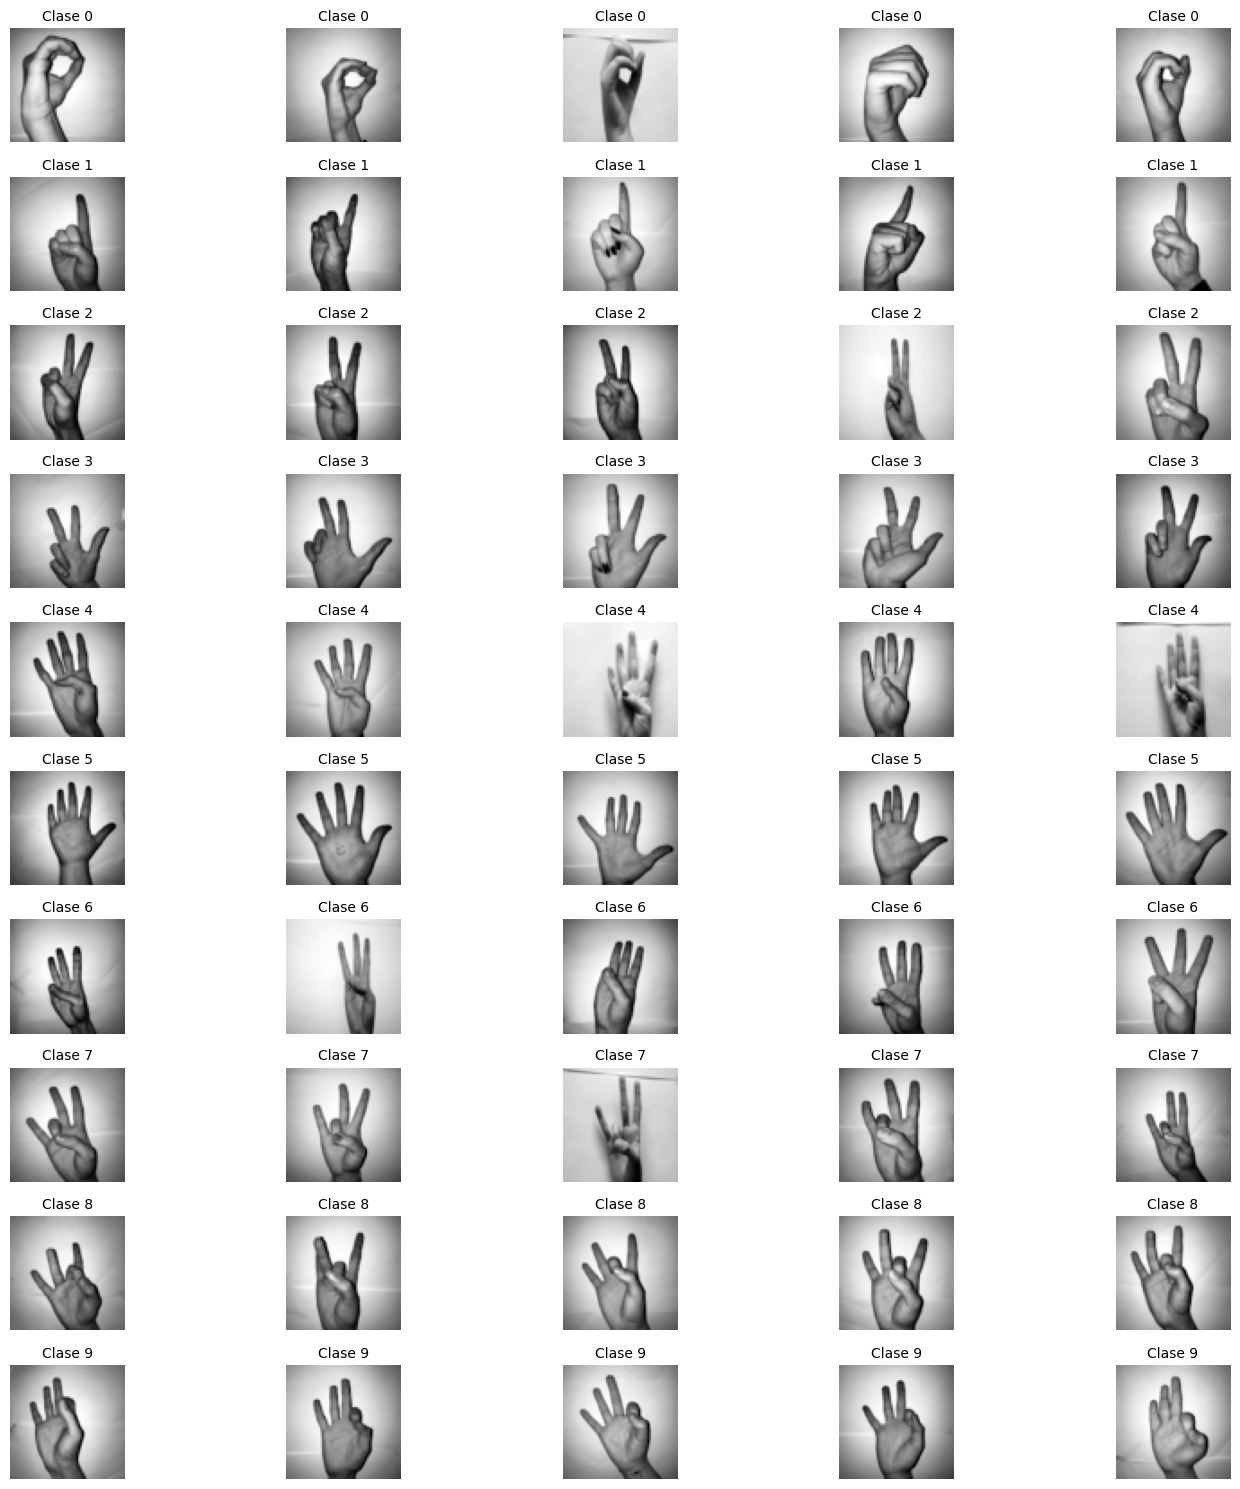

In [107]:
# Usar x_orde y y_orde en lugar de x_load y y_load para visualizar 5 imágenes por clase
import matplotlib.pyplot as plt
import numpy as np

# Obtener etiquetas corregidas como enteros
labels = y_orde
num_classes = len(np.unique(labels))
imagenes_por_clase = 5

# Crear figura con 10 filas (clases) x 5 columnas (imágenes)
fig, axes = plt.subplots(num_classes, imagenes_por_clase, figsize=(15, 15))

for clase in range(num_classes):
    indices = np.where(labels == clase)[0][:imagenes_por_clase]
    for i, idx in enumerate(indices):
        img = x_orde[idx].squeeze()
        ax = axes[clase, i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Clase {clase}', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()



In [108]:
# === 1. IMPORTAR LIBRERÍAS ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [109]:
# Adaptar el código para usar x_orde (imágenes reordenadas)
imagen_shape = x_orde[0].shape
num_imagenes = x_orde.shape[0]

{
    "Número total de imágenes": num_imagenes,
    "Dimensiones de cada imagen": imagen_shape
}



{'Número total de imágenes': 2062, 'Dimensiones de cada imagen': (64, 64, 1)}

In [110]:
# === 2. PREPROCESAMIENTO DE LOS DATOS ===
x_orde = x_orde.astype('float32')  # Asegurar tipo de dato

# Añadir canal si no existe
if x_orde.ndim == 3:
    x_orde = x_orde.reshape(-1, 64, 64, 1)


In [111]:
# ✅ Usar las etiquetas corregidas (alineadas con x_orde)
y_classes = np.argmax(y_orde_onehot, axis=1)


In [112]:
from sklearn.model_selection import train_test_split
import numpy as np

# Etiquetas como enteros (para usar en stratify)
y_classes = np.argmax(y_orde_onehot, axis=1)

# División entrenamiento / test con datos alineados
X_train, X_test, y_train, y_test = train_test_split(
    x_orde, y_orde_onehot,   # ✅ etiquetas corregidas
    test_size=0.2,
    random_state=42,
    stratify=y_classes        # ✅ asegura proporción de clases
)


In [113]:
# === 4. AUGMENTACIÓN DE DATOS ===
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)
datagen.fit(X_train)

In [114]:
# === 5. DEFINICIÓN DEL MODELO CNN ===
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 10 clases
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [115]:
from tensorflow.keras.callbacks import EarlyStopping

# Detener si no mejora la validación por 5 epochs seguidas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [116]:
# === 6. ENTRENAMIENTO DEL MODELO ===
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]  # ✅ Evitar sobreajuste
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.0954 - loss: 2.3099 - val_accuracy: 0.1985 - val_loss: 2.2950
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2100 - loss: 2.2314 - val_accuracy: 0.5835 - val_loss: 1.3872
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4356 - loss: 1.5891 - val_accuracy: 0.7724 - val_loss: 0.7887
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6176 - loss: 1.1208 - val_accuracy: 0.8717 - val_loss: 0.4572
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7188 - loss: 0.8765 - val_accuracy: 0.8862 - val_loss: 0.4152
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7727 - loss: 0.6808 - val_accuracy: 0.9056 - val_loss: 0.3313
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7940 - loss: 0.6767 - val_accuracy: 0.8765 - val_loss: 0.3885
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8122 - loss: 0.5518 - val_accuracy: 0.9370 - 

In [117]:

# === 7. EVALUACIÓN Y MATRIZ DE CONFUSIÓN ===
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


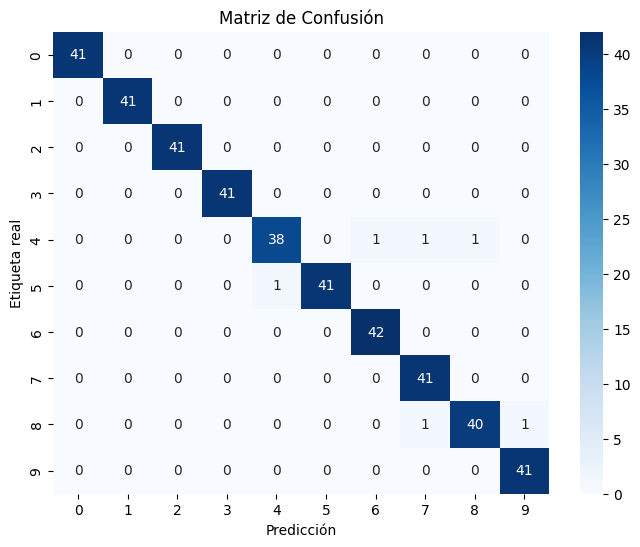

In [118]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión')
plt.show()


Reporte de clasificación:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        41
           3       1.00      1.00      1.00        41
           4       0.97      0.93      0.95        41
           5       1.00      0.98      0.99        42
           6       0.98      1.00      0.99        42
           7       0.95      1.00      0.98        41
           8       0.98      0.95      0.96        42
           9       0.98      1.00      0.99        41

    accuracy                           0.99       413
   macro avg       0.99      0.99      0.99       413
weighted avg       0.99      0.99      0.99       413



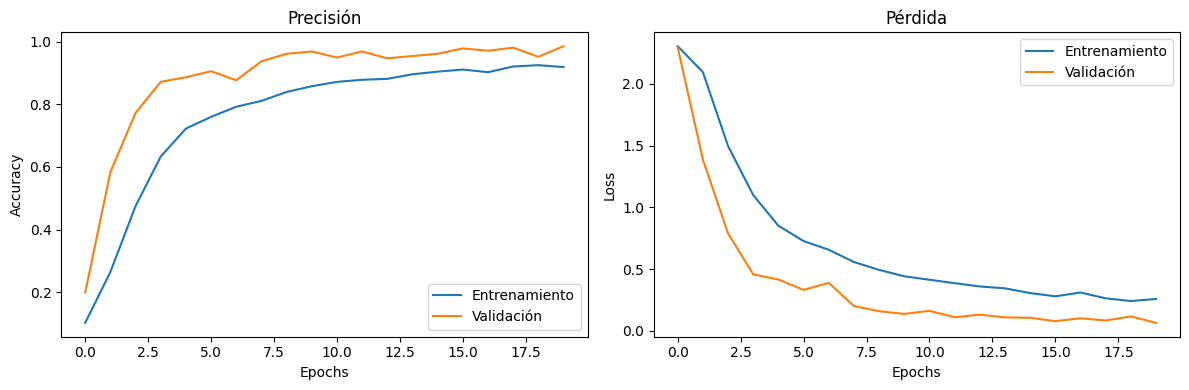

In [119]:
# Reporte de clasificación
print("\nReporte de clasificación:\n")
print(classification_report(y_true, y_pred))

# === 8. GRÁFICAS DE ENTRENAMIENTO ===
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

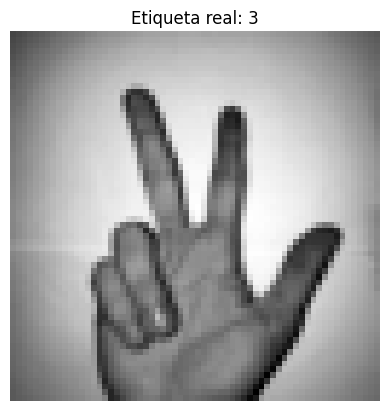

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
🔍 Predicción del modelo: 3
✅ Etiqueta real: 3


In [120]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# === 1. Selecciona una imagen del conjunto de prueba ===
indice = 42  # Puedes cambiar este número
imagen = X_test[indice]
etiqueta_real = np.argmax(y_test[indice])  # Decodifica one-hot

# === 2. Muestra la imagen ===
plt.imshow(imagen.squeeze(), cmap='gray')
plt.title(f"Etiqueta real: {etiqueta_real}")
plt.axis('off')
plt.show()

# === 3. Preprocesa y predice ===
entrada = imagen.reshape(1, 64, 64, 1)  # Asegurar batch size 1
prediccion = model.predict(entrada)
etiqueta_predicha = np.argmax(prediccion)

print(f"🔍 Predicción del modelo: {etiqueta_predicha}")
print(f"✅ Etiqueta real: {etiqueta_real}")


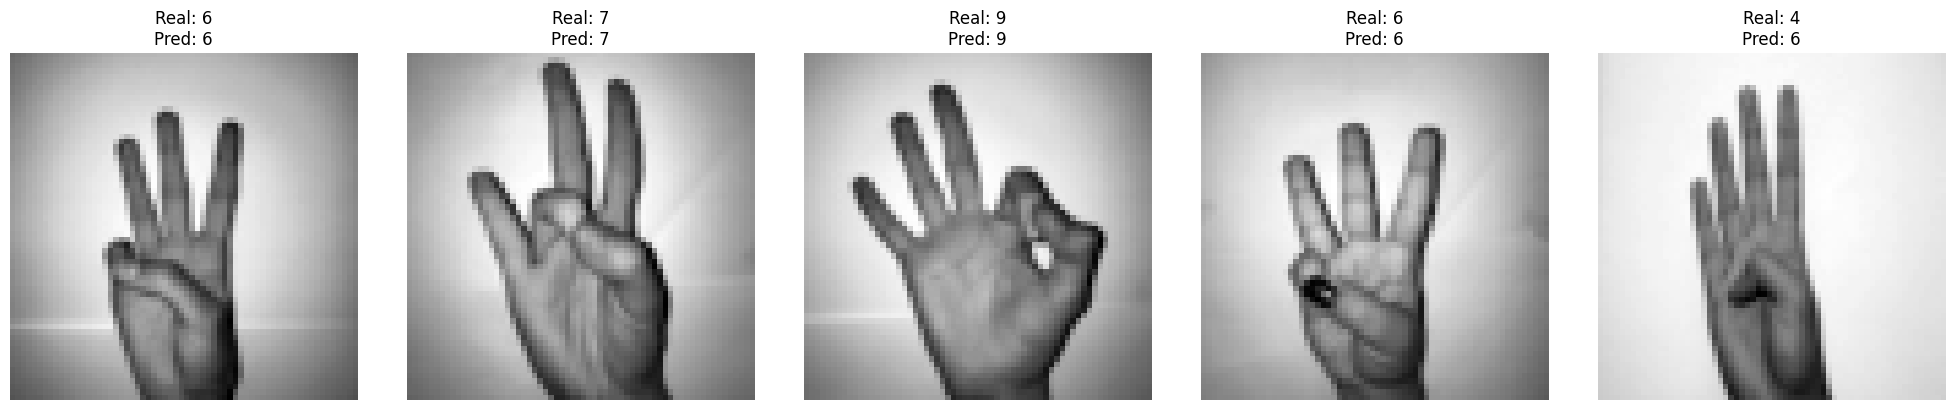

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizar 5 imágenes de prueba con su etiqueta real y predicción del modelo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    imagen = X_test[i]
    etiqueta_real = np.argmax(y_test[i])
    entrada = imagen.reshape(1, 64, 64, 1)  # Asegura batch para el modelo

    # Hacer la predicción
    prediccion = model.predict(entrada, verbose=0)
    etiqueta_predicha = np.argmax(prediccion)

    # Mostrar la imagen con etiquetas
    axes[i].imshow(imagen.squeeze(), cmap='gray')
    axes[i].set_title(f"Real: {etiqueta_real}\nPred: {etiqueta_predicha}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
